**Titanic_classifier_corr 적용**

**(Logistic Regression, Decision Tree, Random Forest)**

In [140]:
# titanic.csv 파일을 불러와 df(DataFrame)에 저장
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [141]:
# 불필요한 칼럼 제거
# PassengerId: 단순 ID
# Name, Ticket, Cabin은 문자열, 모델이 활용하기 어려운 정보
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# 결측치 처리
# Age는 평균 값으로 채움
df['Age'] = df['Age'].fillna(df['Age'].mean())
# Embarked는 최빈값(가장 많이 등장한 값)으로 채움
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

from sklearn.preprocessing import LabelEncoder

# Label Encoding
# 모델은 숫자만 이해할 수 있기 때문에 문자 -> 숫자로 변환
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

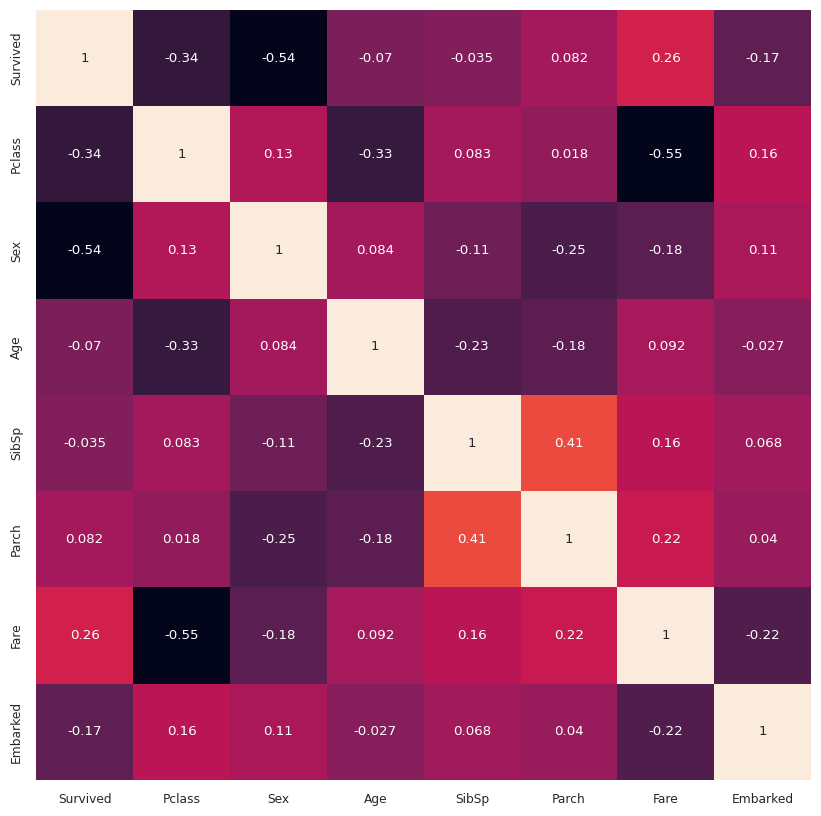

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# 상관계수 계산
df_corr=df.corr()

# 그래프 크기 설정
plt.figure(figsize=(10,10))

sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()


In [143]:
# Sex, Pclass, Fare는 생존 여부와 직접적인 인과/상관 관계가 있는 정보
# Sex는 남성 생존 확률이 낮음(타이타닉 구조 원칙: 여자,아이들 우선)
# Pclass는 객실등급이 낮을 수록 생존 확률이 낮음
# Fare는 승선하기 위해 지불한 요금이 높을 수록 생존 확률이 높음
X = df[['Sex', 'Pclass', 'Fare']]
X.head()

,Sex,Pclass,Fare
0,1,3,7.2500
1,0,1,71.2833
2,0,3,7.9250
3,0,1,53.1000
4,1,3,8.0500


In [144]:
#정답값 설정
y=df['Survived']
y.value_counts()

,count
Survived,
0,549
1,342


In [145]:
# 데이터를 학습용(train)과 테스트용(test)으로 나누기 (25%는 테스트 데이터)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=42)

In [146]:
from sklearn.preprocessing import StandardScaler

#데이터의 크기(스케일)를 통일해서 모델이 공정하게 학습
scaler = StandardScaler()

# 학습 데이터의 평균과 표준편차를 기준으로 스케일을 맞추기 위해 fit(기준 학습)과 transform(변환)을 동시에 수행
X_train = scaler.fit_transform(X_train)

# 학습 데이터에서 만든 기준(평균, 표준편차)을 그대로 적용하여 테스트 데이터를 동일한 스케일로 변환
# fit을 안하는 이유 : test 데이터로 fit을 하면 평가 전에 test 정보를 사용하게 되어 데이터 누수가 발생
X_test  = scaler.transform(X_test)

In [147]:
# 라이브러리 import
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings

In [148]:
# Build a logistic regression classifier and predict

clf_lr = LogisticRegression()   # 로지스틱 회귀 모델 생성(반복하는 최대 횟수 지정)
clf_lr.fit(X_train, y_train)                                 # 학습용 데이터로 모델 학습(fit)

pred_lr = clf_lr.predict(X_test)                             # 테스트 데이터로 예측 수행

print("--- Logistic Regression Classifier ---")
print(accuracy_score(y_test, pred_lr))                       # 예측 정확도 출력
print(confusion_matrix(y_test, pred_lr))                     # 혼동행렬(모델이 어디서 틀렸는지 보여주는 표) 출력

report = classification_report(y_test, pred_lr)              # 전체 리포트
print("\nClassification Report:\n", report)

--- Logistic Regression Classifier ---
0.7802690582959642
[[111  23]
 [ 26  63]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       134
           1       0.73      0.71      0.72        89

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223



In [151]:
# Build a decision tree classifier and predict

clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print ("--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))

report = classification_report(y_test, pred_dt)              # 전체 리포트
print("\nClassification Report:\n", report)

--- Decision Tree Classifier ---
0.820627802690583
[[122  12]
 [ 28  61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       134
           1       0.84      0.69      0.75        89

    accuracy                           0.82       223
   macro avg       0.82      0.80      0.81       223
weighted avg       0.82      0.82      0.82       223



In [152]:
# Build a radom Forest classifier and predict

warnings.filterwarnings('ignore')

print ("--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print(accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))

report = classification_report(y_test, pred)              # 전체 리포트
print("\nClassification Report:\n", report)

--- Radom Forest ---
0.8251121076233184
[[117  17]
 [ 22  67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86       134
           1       0.80      0.75      0.77        89

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.82       223
weighted avg       0.82      0.83      0.82       223

